In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
folder_path ='/content/drive/MyDrive/Data Science/datasets/'
file_path=folder_path+'heart.csv'
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(file_path)
print("dataset info:")
print(df.info())
df
print("\nПропуски:", df.isnull().sum().sum())


dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None

Пропуски: 0


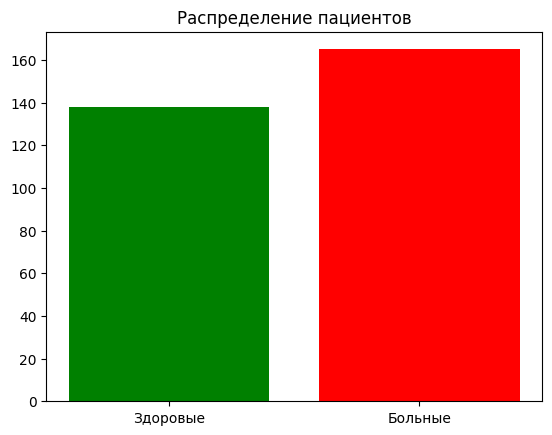

In [ ]:
counts = df['target'].value_counts().sort_index()
plt.bar(['Здоровые', 'Больные'], counts.values, color=['green', 'red'])
plt.title('Распределение пациентов')
plt.show()

In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1VVNE_EEKtDQ9vGnII_8V8KyaiUJMGd-6wb3GttzPHEA/edit#gid=0


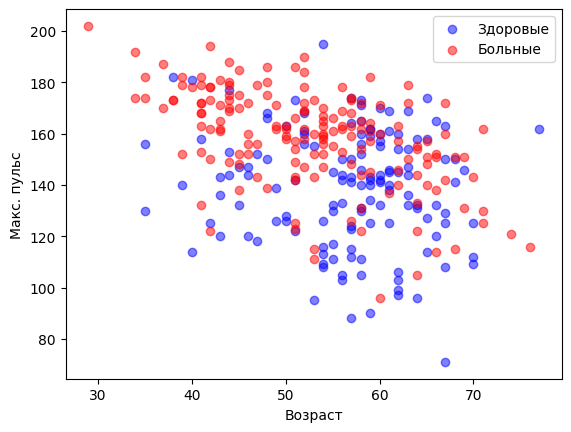

In [ ]:
plt.scatter(df[df['target']==0]['age'], df[df['target']==0]['thalach'], color='blue', label='Здоровые', alpha=0.5)
plt.scatter(df[df['target']==1]['age'], df[df['target']==1]['thalach'], color='red', label='Больные', alpha=0.5)
plt.xlabel('Возраст')
plt.ylabel('Макс. пульс')
plt.legend()
plt.show()

In [ ]:
df['sex'] = df['sex'].map({0: 'female', 1: 'male'})
df


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,male,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,male,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,female,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,male,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,female,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,female,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,male,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,male,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,male,0,130,131,0,1,115,1,1.2,1,1,3,0


In [ ]:
df = pd.get_dummies(df, columns=['sex'], dtype=int)
df

,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_female,sex_male
0,63,3,145,233,1,0,150,0,2.3,0,0,1,1,0,1
1,37,2,130,250,0,1,187,0,3.5,0,0,2,1,0,1
2,41,1,130,204,0,0,172,0,1.4,2,0,2,1,1,0
3,56,1,120,236,0,1,178,0,0.8,2,0,2,1,0,1
4,57,0,120,354,0,1,163,1,0.6,2,0,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,140,241,0,1,123,1,0.2,1,0,3,0,1,0
299,45,3,110,264,0,1,132,0,1.2,1,0,3,0,0,1
300,68,0,144,193,1,1,141,0,3.4,1,2,3,0,0,1
301,57,0,130,131,0,1,115,1,1.2,1,1,3,0,0,1


In [ ]:
mean_chol = df.groupby('target')['chol'].mean()
print(f"\nСредний холестерин:\nЗдоровые: {mean_chol[0]:.2f}\nБольные: {mean_chol[1]:.2f}")


Средний холестерин:
Здоровые: 251.09
Больные: 242.23


In [ ]:
cols_to_norm = ['age', 'trestbps', 'chol', 'thalach']
for col in cols_to_norm:
    df[col] = (df[col] - df[col].mean()) / df[col].std()

print("\nДанные после нормализации (describe):")
print(df[cols_to_norm].describe())
df



Данные после нормализации (describe):
                age      trestbps          chol       thalach
count  3.030000e+02  3.030000e+02  3.030000e+02  3.030000e+02
mean   2.345026e-17 -1.172513e-17  2.931282e-17  4.690051e-17
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00
min   -2.793003e+00 -2.145254e+00 -2.320322e+00 -3.433587e+00
25%   -7.560295e-01 -6.627704e-01 -6.803688e-01 -7.049444e-01
50%    6.977057e-02 -9.258463e-02 -1.208554e-01  1.463921e-01
75%    7.304107e-01  4.776012e-01  5.447726e-01  7.139498e-01
max    2.492118e+00  3.898716e+00  6.130260e+00  2.285648e+00


,age,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,sex_female,sex_male
0,0.950624,3,0.762694,-0.255910,1,0,0.015417,0,2.3,0,0,1,1,0,1
1,-1.912150,2,-0.092585,0.072080,0,1,1.630774,0,3.5,0,0,2,1,0,1
2,-1.471723,1,-0.092585,-0.815424,0,0,0.975900,0,1.4,2,0,2,1,1,0
3,0.179877,1,-0.662770,-0.198030,0,1,1.237849,0,0.8,2,0,2,1,0,1
4,0.289984,0,-0.662770,2.078611,0,1,0.582975,1,0.6,2,0,2,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,0.289984,0,0.477601,-0.101562,0,1,-1.163356,1,0.2,1,0,3,0,1,0
299,-1.031296,3,-1.232956,0.342190,0,1,-0.770432,0,1.2,1,0,3,0,0,1
300,1.501157,0,0.705675,-1.027653,1,1,-0.377507,0,3.4,1,2,3,0,0,1
301,0.289984,0,-0.092585,-2.223854,0,1,-1.512623,1,1.2,1,1,3,0,0,1
